# 🌦️ WeatherWise

## Setup and Configuration

In [1]:
!pip install pyinputplus
!pip install matplotlib


[notice] A new release of pip available: 22.3 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import requests
import matplotlib.pyplot as plt
import pyinputplus as pyip
from fetch_my_weather import get_weather
import json

## Weather Data Functions

In [3]:
def get_weather_data(location, forecast_days=5):
    """
    Retrieve weather data for a specified location.
    """
    try:
        if not isinstance(forecast_days, int) or forecast_days < 1 or forecast_days > 5:
            print("Warning: forecast_days must be between 1 and 5. Using default value of 5.")
            forecast_days = 5

        weather_result = get_weather(location)
        if weather_result is None:
            print(f"Error: Could not retrieve weather data for '{location}'")
            return None

        # Normalize to dict
        if hasattr(weather_result, "model_dump"):  # Pydantic v2
            data = weather_result.model_dump()
        elif hasattr(weather_result, "dict"):      # Pydantic v1
            data = weather_result.dict()
        elif isinstance(weather_result, str):      # JSON string
            try:
                data = json.loads(weather_result)
            except Exception:
                print(f"Error: Unexpected response type (str not JSON)")
                return None
        elif isinstance(weather_result, dict):     # Already dict
            data = weather_result
        else:
            print(f"Error: Unexpected response type: {type(weather_result)}")
            return None

        structured_data = {
            'location': location,
            'current': {
                'temperature': data.get('current_condition', [{}])[0].get('temp_C', 'N/A'),
                'feels_like': data.get('current_condition', [{}])[0].get('FeelsLikeC', 'N/A'),
                'description': data.get('current_condition', [{}])[0].get('weatherDesc', [{}])[0].get('value', 'N/A'),
                'humidity': data.get('current_condition', [{}])[0].get('humidity', 'N/A'),
                'wind_speed': data.get('current_condition', [{}])[0].get('windspeedKmph', 'N/A'),
                'precipitation': data.get('current_condition', [{}])[0].get('precipMM', 'N/A')
            },
            'forecast': []
        }

        forecast_data = data.get('weather', [])
        for day in forecast_data[:forecast_days]:
            forecast_entry = {
                'date': day.get('date', 'N/A'),
                'max_temp': day.get('maxtempC', 'N/A'),
                'min_temp': day.get('mintempC', 'N/A'),
                'avg_temp': day.get('avgtempC', 'N/A'),
                'description': day.get('hourly', [{}])[0].get('weatherDesc', [{}])[0].get('value', 'N/A'),
                'precipitation_mm': day.get('hourly', [{}])[0].get('precipMM', '0'),
                'chance_of_rain': day.get('hourly', [{}])[0].get('chanceofrain', '0'),
                'humidity': day.get('hourly', [{}])[0].get('humidity', 'N/A')
            }
            structured_data['forecast'].append(forecast_entry)

        return structured_data

    except Exception as e:
        print(f"Error retrieving weather data: {str(e)}")
        return None

## Visualisation Functions

In [4]:
def create_temperature_visualisation(weather_data, output_type='display'):
    """
    Create visualisation of temperature data.

    Args:
        weather_data (dict): The processed weather data
        output_type (str): Either 'display' to show in notebook or 'figure' to return the figure

    Returns:
        matplotlib.figure.Figure: The figure object (always returned)
    """
    if weather_data is None or 'forecast' not in weather_data:
        print("Error: Invalid weather data provided")
        return None
    
    try:
        # Extract temperature data from forecast
        dates = []
        max_temps = []
        min_temps = []
        avg_temps = []
        
        for day in weather_data['forecast']:
            dates.append(day['date'])
            try:
                max_temps.append(float(day['max_temp']))
                min_temps.append(float(day['min_temp']))
                avg_temps.append(float(day['avg_temp']))
            except (ValueError, TypeError):
                # Handle cases where temperature data is missing
                max_temps.append(None)
                min_temps.append(None)
                avg_temps.append(None)
        
        # Create the figure
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Plot temperature lines
        ax.plot(dates, max_temps, marker='o', linewidth=2, label='Max Temp', color='#FF6B6B')
        ax.plot(dates, avg_temps, marker='s', linewidth=2, label='Avg Temp', color='#4ECDC4')
        ax.plot(dates, min_temps, marker='^', linewidth=2, label='Min Temp', color='#45B7D1')
        
        # Fill area between max and min
        ax.fill_between(dates, max_temps, min_temps, alpha=0.2, color='#95E1D3')
        
        # Customize the plot
        ax.set_xlabel('Date', fontsize=12, fontweight='bold')
        ax.set_ylabel('Temperature (°C)', fontsize=12, fontweight='bold')
        ax.set_title(f'Temperature Forecast for {weather_data["location"]}', 
                     fontsize=14, fontweight='bold', pad=20)
        ax.legend(loc='best', framealpha=0.9)
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Rotate x-axis labels for better readability
        plt.xticks(rotation=45, ha='right')
        
        # Add current temperature annotation if available
        if 'current' in weather_data:
            current_temp = weather_data['current'].get('temperature', 'N/A')
            if current_temp != 'N/A':
                ax.text(0.02, 0.98, f'Current: {current_temp}°C', 
                       transform=ax.transAxes, fontsize=10,
                       verticalalignment='top', bbox=dict(boxstyle='round', 
                       facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        
        # Display if requested, but always return the figure
        if output_type == 'display':
            plt.show()
        
        return fig
            
    except Exception as e:
        print(f"Error creating temperature visualisation: {str(e)}")
        return None

In [5]:
def create_precipitation_visualisation(weather_data, output_type='display'):
    """
    Create visualisation of precipitation data.

    Args:
        weather_data (dict): The processed weather data
        output_type (str): Either 'display' to show in notebook or 'figure' to return the figure

    Returns:
        matplotlib.figure.Figure: The figure object (always returned)
    """
    if weather_data is None or 'forecast' not in weather_data:
        print("Error: Invalid weather data provided")
        return None
    
    try:
        # Extract precipitation data from forecast
        dates = []
        precipitation_amounts = []
        rain_chances = []
        
        for day in weather_data['forecast']:
            dates.append(day['date'])
            try:
                # Get precipitation amount in mm
                precip_mm = float(day.get('precipitation_mm', 0))
                precipitation_amounts.append(precip_mm)
                
                # Get chance of rain as percentage
                rain_chance = float(day.get('chance_of_rain', 0))
                rain_chances.append(rain_chance)
            except (ValueError, TypeError):
                precipitation_amounts.append(0)
                rain_chances.append(0)
        
        # Create figure with two subplots
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
        
        # Top plot: Precipitation amount (bar chart)
        bars = ax1.bar(dates, precipitation_amounts, color='#3498DB', alpha=0.7, edgecolor='#2980B9', linewidth=1.5)
        ax1.set_ylabel('Precipitation (mm)', fontsize=11, fontweight='bold')
        ax1.set_title(f'Precipitation Forecast for {weather_data["location"]}', 
                     fontsize=14, fontweight='bold', pad=15)
        ax1.grid(True, alpha=0.3, linestyle='--', axis='y')
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax1.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.1f}mm',
                        ha='center', va='bottom', fontsize=9)
        
        # Bottom plot: Chance of rain (line chart with area fill)
        ax2.fill_between(dates, rain_chances, alpha=0.3, color='#9B59B6')
        ax2.plot(dates, rain_chances, marker='o', linewidth=2, color='#8E44AD', markersize=8)
        ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Chance of Rain (%)', fontsize=11, fontweight='bold')
        ax2.set_ylim(0, 100)
        ax2.grid(True, alpha=0.3, linestyle='--')
        
        # Add percentage labels on points
        for i, (date, chance) in enumerate(zip(dates, rain_chances)):
            if chance > 5:  # Only show label if chance is significant
                ax2.text(i, chance + 3, f'{chance:.0f}%', 
                        ha='center', fontsize=9, fontweight='bold')
        
        # Rotate x-axis labels for both plots
        ax1.tick_params(axis='x', rotation=45)
        ax2.tick_params(axis='x', rotation=45)
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        plt.tight_layout()
        
        # Display if requested, but always return the figure
        if output_type == 'display':
            plt.show()
        
        return fig
            
    except Exception as e:
        print(f"Error creating precipitation visualisation: {str(e)}")
        return None

## Natural Language Processing

In [6]:
def parse_weather_question(question):
    """
    Parse a natural language weather question.
    """
    if not question or not isinstance(question, str):
        return {
            'location': None,
            'time_period': 'today',
            'attribute': 'general',
            'original_question': question
        }

    question_lower = question.lower()

    result = {
        'location': None,
        'time_period': 'today',
        'attribute': 'general',
        'original_question': question
    }

    time_keywords = {
        'today': ['today', 'right now', 'currently', 'now', 'this moment'],
        'tomorrow': ['tomorrow', 'next day'],
        'weekend': ['weekend', 'saturday', 'sunday'],
        'week': ['this week', 'next week', 'coming week', 'week'],
        'day_after': ['day after tomorrow', 'overmorrow']
    }
    for period, keywords in time_keywords.items():
        for keyword in keywords:
            if keyword in question_lower:
                result['time_period'] = period
                break

    attribute_keywords = {
        'temperature': ['temperature', 'temp', 'hot', 'cold', 'warm', 'cool', 'degrees', 'celsius', 'fahrenheit'],
        'rain': ['rain', 'raining', 'rainy', 'precipitation', 'drizzle', 'showers', 'umbrella', 'wet'],
        'wind': ['wind', 'windy', 'breeze', 'gust'],
        'humidity': ['humidity', 'humid', 'moisture', 'damp'],
        'conditions': ['condition', 'weather', 'forecast', 'like', 'look like', 'expect'],
        'sunny': ['sunny', 'sun', 'clear', 'sunshine'],
        'cloudy': ['cloud', 'cloudy', 'overcast']
    }
    for attribute, keywords in attribute_keywords.items():
        for keyword in keywords:
            if keyword in question_lower:
                result['attribute'] = attribute
                break

    # Extract location
    import re
    in_pattern = re.search(r'\bin\s+([A-Z][a-z]+(?:\s+[A-Z][a-z]+)*)', question)
    if in_pattern:
        result['location'] = in_pattern.group(1)
    if not result['location']:
        at_pattern = re.search(r'\bat\s+([A-Z][a-z]+(?:\s+[A-Z][a-z]+)*)', question)
        if at_pattern:
            result['location'] = at_pattern.group(1)
    if not result['location']:
        for_pattern = re.search(r'\bfor\s+([A-Z][a-z]+(?:\s+[A-Z][a-z]+)*)', question)
        if for_pattern:
            result['location'] = for_pattern.group(1)

    if result['location']:
        time_tokens = set([
            'today', 'tomorrow', 'week', 'weekend', 'saturday', 'sunday',
            'monday','tuesday','wednesday','thursday','friday',
            'tonight','now','currently','next','this'
        ])
        parts = result['location'].split()
        while parts and parts[-1].strip(".,!?").lower() in time_tokens:
            parts.pop()
        result['location'] = " ".join(parts) if parts else None

    return result

## User Interface

In [7]:
# Define menu functions using pyinputplus or ipywidgets here

def display_current_weather(location):
    """Display current weather conditions for a location."""
    print(f"\n{'='*60}")
    print(f"  CURRENT WEATHER FOR {location.upper()}")
    print(f"{'='*60}\n")
    
    weather_data = get_weather_data(location, forecast_days=5)
    
    if weather_data is None:
        print("❌ Unable to retrieve weather data. Please check the location name.")
        return
    
    current = weather_data['current']
    print(f"🌡️  Temperature:    {current['temperature']}°C (feels like {current['feels_like']}°C)")
    print(f"☁️  Conditions:     {current['description']}")
    print(f"💧 Humidity:       {current['humidity']}%")
    print(f"💨 Wind Speed:     {current['wind_speed']} km/h")
    print(f"🌧️  Precipitation:  {current['precipitation']}mm")
    print(f"\n{'='*60}\n")

def display_forecast(location, days=5):
    """Display weather forecast for a location."""
    print(f"\n{'='*60}")
    print(f"  {days}-DAY FORECAST FOR {location.upper()}")
    print(f"{'='*60}\n")
    
    weather_data = get_weather_data(location, forecast_days=days)
    
    if weather_data is None:
        print("❌ Unable to retrieve weather data. Please check the location name.")
        return
    
    for i, day in enumerate(weather_data['forecast']):
        day_label = "Today" if i == 0 else "Tomorrow" if i == 1 else f"Day {i+1}"
        print(f"📅 {day_label} ({day['date']})")
        print(f"   🌡️  High: {day['max_temp']}°C | Low: {day['min_temp']}°C | Avg: {day['avg_temp']}°C")
        print(f"   ☁️  {day['description']}")
        print(f"   🌧️  Rain Chance: {day['chance_of_rain']}% | Precipitation: {day['precipitation_mm']}mm")
        print()
    
    print(f"{'='*60}\n")

def ask_weather_question():
    """Handle natural language weather questions."""
    print(f"\n{'='*60}")
    print("  ASK A WEATHER QUESTION")
    print(f"{'='*60}\n")
    print("Ask me anything about the weather!")
    print("Examples:")
    print("  - What's the temperature in London today?")
    print("  - Will it rain in Sydney tomorrow?")
    print("  - How's the weather in Perth this week?")
    print()
    
    question = pyip.inputStr("Your question: ", blank=False)
    
    # Parse the question
    parsed = parse_weather_question(question)
    
    # Get location if not found in question
    location = parsed['location']
    if not location:
        location = pyip.inputStr("\nWhich location would you like to know about? ", blank=False)
        parsed['location'] = location
    
    print(f"\n🤔 Understanding your question...")
    print(f"   Location: {location}")
    print(f"   Time: {parsed['time_period']}")
    print(f"   About: {parsed['attribute']}")
    print()
    
    # Get weather data
    weather_data = get_weather_data(location, forecast_days=5)
    
    if weather_data is None:
        print("❌ Unable to retrieve weather data for that location.")
        return
    
    # Generate response
    response = generate_weather_response(parsed, weather_data)
    print(f"\n💬 {response}\n")
    print(f"{'='*60}\n")

def show_visualizations(location):
    """Display weather visualizations for a location."""
    print(f"\n{'='*60}")
    print(f"  WEATHER VISUALIZATIONS FOR {location.upper()}")
    print(f"{'='*60}\n")
    
    weather_data = get_weather_data(location, forecast_days=5)
    
    if weather_data is None:
        print("❌ Unable to retrieve weather data. Please check the location name.")
        return
    
    print("Generating temperature visualization...\n")
    create_temperature_visualisation(weather_data, output_type='display')
    
    print("\nGenerating precipitation visualization...\n")
    create_precipitation_visualisation(weather_data, output_type='display')
    
    print(f"\n{'='*60}\n")

def main_menu():
    """Display and handle the main menu."""
    print("\n" + "="*60)
    print(" "*15 + "🌦️  WEATHERWISE ADVISOR  🌦️")
    print("="*60)
    print("\nYour intelligent weather analysis & advisory system")
    print("\nWhat would you like to do?\n")
    
    menu_options = [
        "Get Current Weather",
        "Get Weather Forecast (5 days)",
        "Ask a Weather Question (Natural Language)",
        "View Weather Visualizations",
        "Exit"
    ]
    
    for option in menu_options:
        print(f"   {option}")
    
    print("\n" + "="*60)
    
    choice = pyip.inputMenu(menu_options, numbered=True, blank=False)
    
    return choice

def run_weather_advisor():
    """Main application loop."""
    while True:
        choice = main_menu()
        
        if "Exit" in choice:
            print("\n" + "="*60)
            print(" "*10 + "Thank you for using WeatherWise!")
            print(" "*15 + "Stay weather-aware! 🌈")
            print("="*60 + "\n")
            break
        
        elif "Current Weather" in choice:
            location = pyip.inputStr("\nEnter location (city name): ", blank=False)
            display_current_weather(location)
        
        elif "Forecast" in choice:
            location = pyip.inputStr("\nEnter location (city name): ", blank=False)
            days = pyip.inputInt("\nNumber of days to forecast (1-5): ", min=1, max=5, default=5)
            display_forecast(location, days)
        
        elif "Question" in choice:
            ask_weather_question()
        
        elif "Visualizations" in choice:
            location = pyip.inputStr("\nEnter location (city name): ", blank=False)
            show_visualizations(location)

## Main Application Logic


               🌦️  WEATHERWISE ADVISOR  🌦️

Your intelligent weather analysis & advisory system

What would you like to do?

   Get Current Weather
   Get Weather Forecast (5 days)
   Ask a Weather Question (Natural Language)
   View Weather Visualizations
   Exit

Please select one of the following:
1. Get Current Weather
2. Get Weather Forecast (5 days)
3. Ask a Weather Question (Natural Language)
4. View Weather Visualizations
5. Exit


 1



Enter location (city name): 

 Perth



  CURRENT WEATHER FOR PERTH

🌡️  Temperature:    21°C (feels like 21°C)
☁️  Conditions:     Partly cloudy
💧 Humidity:       49%
💨 Wind Speed:     18 km/h
🌧️  Precipitation:  0.0mm



               🌦️  WEATHERWISE ADVISOR  🌦️

Your intelligent weather analysis & advisory system

What would you like to do?

   Get Current Weather
   Get Weather Forecast (5 days)
   Ask a Weather Question (Natural Language)
   View Weather Visualizations
   Exit

Please select one of the following:
1. Get Current Weather
2. Get Weather Forecast (5 days)
3. Ask a Weather Question (Natural Language)
4. View Weather Visualizations
5. Exit


...


🤔 Understanding your question...
   Location: Lucknow
   Time: tomorrow
   About: humidity


💬 Tomorrow's weather in Lucknow: Clear , with temperatures between 24°C and 33°C. Chance of rain: 0%.



               🌦️  WEATHERWISE ADVISOR  🌦️

Your intelligent weather analysis & advisory system

What would you like to do?

   Get Current Weather
   Get Weather Forecast (5 days)
   Ask a Weather Question (Natural Language)
   View Weather Visualizations
   Exit

Please select one of the following:
1. Get Current Weather
2. Get Weather Forecast (5 days)
3. Ask a Weather Question (Natural Language)
4. View Weather Visualizations
5. Exit


 4



Enter location (city name): 

 Kochi



  WEATHER VISUALIZATIONS FOR KOCHI

Generating temperature visualization...



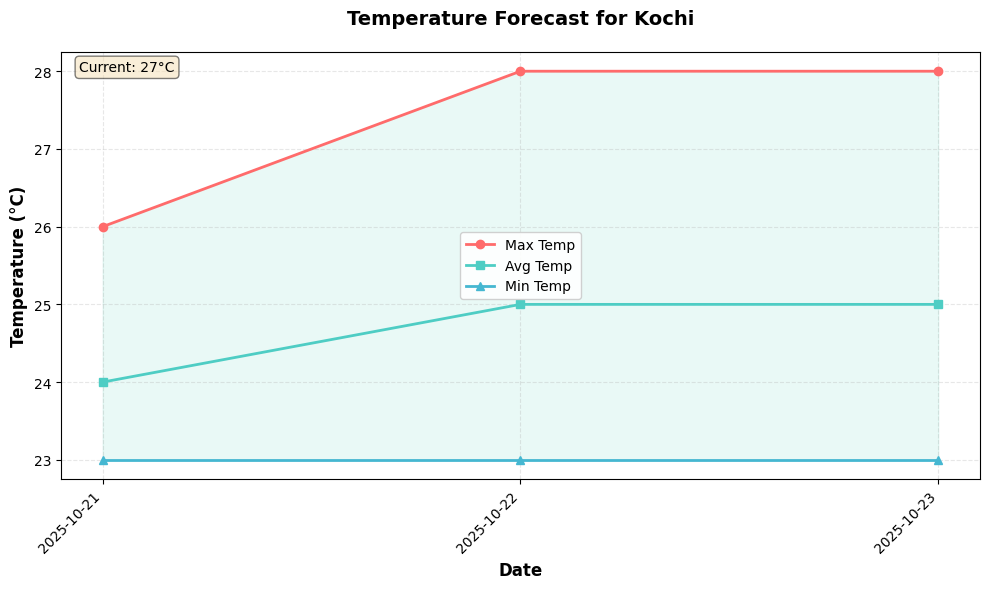


Generating precipitation visualization...



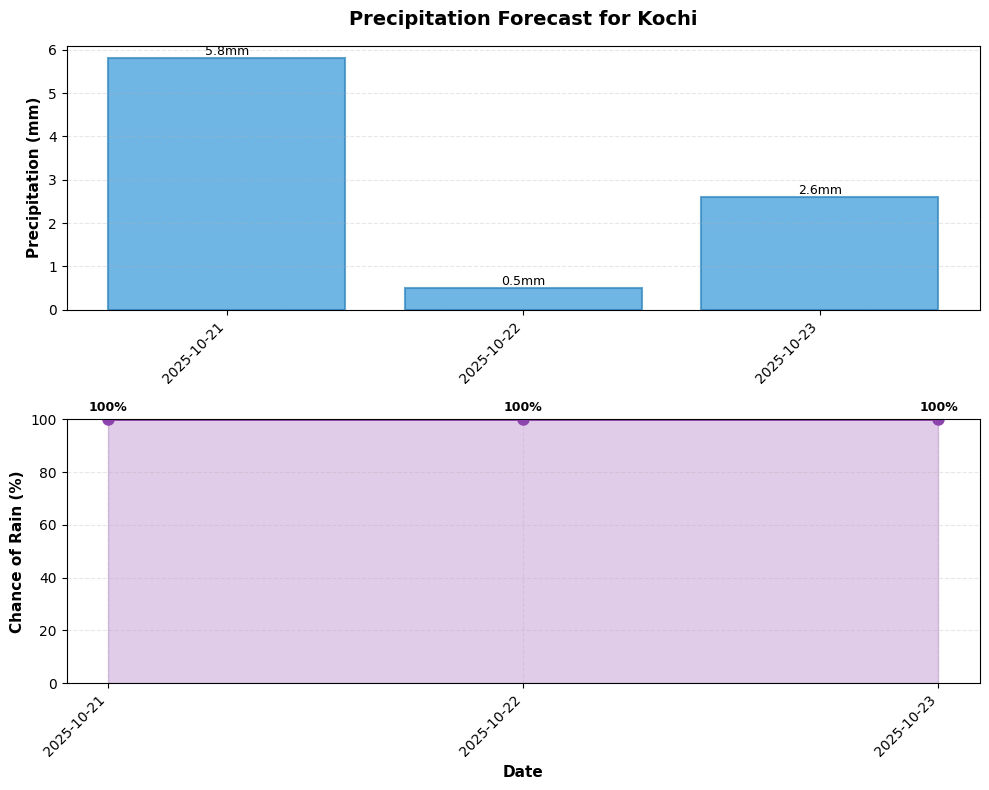




               🌦️  WEATHERWISE ADVISOR  🌦️

Your intelligent weather analysis & advisory system

What would you like to do?

   Get Current Weather
   Get Weather Forecast (5 days)
   Ask a Weather Question (Natural Language)
   View Weather Visualizations
   Exit

Please select one of the following:
1. Get Current Weather
2. Get Weather Forecast (5 days)
3. Ask a Weather Question (Natural Language)
4. View Weather Visualizations
5. Exit


 5



          Thank you for using WeatherWise!
               Stay weather-aware! 🌈



In [11]:
# Tie everything together here
def generate_weather_response(parsed_question, weather_data):
    """
    Generate a natural language response to a weather question.

    Args:
        parsed_question (dict): Parsed question data
        weather_data (dict): Weather data

    Returns:
        str: Natural language response
    """
    if weather_data is None:
        return "I'm sorry, I couldn't retrieve the weather data at this time. Please check the location and try again."
    
    location = weather_data.get('location', 'your location')
    time_period = parsed_question.get('time_period', 'today')
    attribute = parsed_question.get('attribute', 'general')
    
    # Get relevant data based on time period
    if time_period == 'today':
        if 'current' in weather_data:
            current = weather_data['current']
            temp = current.get('temperature', 'N/A')
            feels_like = current.get('feels_like', 'N/A')
            description = current.get('description', 'N/A')
            humidity = current.get('humidity', 'N/A')
            wind_speed = current.get('wind_speed', 'N/A')
            
            if attribute == 'temperature':
                response = f"The current temperature in {location} is {temp}°C (feels like {feels_like}°C)."
            elif attribute == 'rain':
                precip = current.get('precipitation', 'N/A')
                response = f"Currently in {location}, there is {precip}mm of precipitation. The conditions are {description}."
            elif attribute == 'wind':
                response = f"The wind speed in {location} is currently {wind_speed} km/h."
            elif attribute == 'humidity':
                response = f"The humidity in {location} is {humidity}%."
            else:
                response = f"Current weather in {location}: {description}, {temp}°C (feels like {feels_like}°C), {humidity}% humidity, wind at {wind_speed} km/h."
        else:
            response = f"Current weather data is not available for {location}."
    
    elif time_period == 'tomorrow' and len(weather_data.get('forecast', [])) > 1:
        tomorrow = weather_data['forecast'][1]
        max_temp = tomorrow.get('max_temp', 'N/A')
        min_temp = tomorrow.get('min_temp', 'N/A')
        description = tomorrow.get('description', 'N/A')
        rain_chance = tomorrow.get('chance_of_rain', '0')
        
        if attribute == 'temperature':
            response = f"Tomorrow in {location}, temperatures will range from {min_temp}°C to {max_temp}°C."
        elif attribute == 'rain':
            response = f"Tomorrow in {location} has a {rain_chance}% chance of rain. Conditions: {description}."
        else:
            response = f"Tomorrow's weather in {location}: {description}, with temperatures between {min_temp}°C and {max_temp}°C. Chance of rain: {rain_chance}%."
    
    elif time_period in ['week', 'weekend']:
        if len(weather_data.get('forecast', [])) > 0:
            # Summarize the forecast
            forecast_days = weather_data['forecast'][:5]
            avg_high = sum(float(day.get('max_temp', 0)) for day in forecast_days if day.get('max_temp', 'N/A') != 'N/A') / len(forecast_days)
            avg_low = sum(float(day.get('min_temp', 0)) for day in forecast_days if day.get('min_temp', 'N/A') != 'N/A') / len(forecast_days)
            
            # Check for rain
            rainy_days = sum(1 for day in forecast_days if float(day.get('chance_of_rain', 0)) > 50)
            
            if attribute == 'temperature':
                response = f"This week in {location}, average high temperatures will be around {avg_high:.1f}°C and lows around {avg_low:.1f}°C."
            elif attribute == 'rain':
                response = f"This week in {location}, expect rain on approximately {rainy_days} day(s)."
            else:
                response = f"This week's weather in {location}: Average highs of {avg_high:.1f}°C and lows of {avg_low:.1f}°C, with rain expected on about {rainy_days} day(s)."
        else:
            response = f"Extended forecast data is not available for {location}."
    
    else:
        # Default to showing first forecast day
        if len(weather_data.get('forecast', [])) > 0:
            day = weather_data['forecast'][0]
            max_temp = day.get('max_temp', 'N/A')
            min_temp = day.get('min_temp', 'N/A')
            description = day.get('description', 'N/A')
            response = f"Weather for {location}: {description}, temperatures between {min_temp}°C and {max_temp}°C."
        else:
            response = f"Weather forecast is not available for {location}."
    
    return response


run_weather_advisor()


## Testing and Examples

Starting comprehensive testing...
🌦️ COMPREHENSIVE WEATHERWISE TESTING SUITE

📍 TESTING MULTIPLE LOCATIONS
--------------------------------------------------

Testing: London
✅ SUCCESS - London
   Current: 12°C
   Forecast days: 3

Testing: New York
✅ SUCCESS - New York
   Current: 12°C
   Forecast days: 3

Testing: Sydney
✅ SUCCESS - Sydney
   Current: 20°C
   Forecast days: 3

Testing: Tokyo
✅ SUCCESS - Tokyo
   Current: 17°C
   Forecast days: 3

Testing: Mumbai
✅ SUCCESS - Mumbai
   Current: 34°C
   Forecast days: 3

Testing: São Paulo
✅ SUCCESS - São Paulo
   Current: 11°C
   Forecast days: 3

Testing: Cairo
✅ SUCCESS - Cairo
   Current: 23°C
   Forecast days: 3

Testing: InvalidCity12345
Error: Unexpected response type (str not JSON)
❌ FAILED - InvalidCity12345

Location Test Results: 7 successful, 1 failed

📊 TESTING FORECAST DAYS
--------------------------------------------------

Testing 1 day(s) forecast for London:
✅ Requested: 1, Got: 1 days

Testing 3 day(s) forecast for Lo

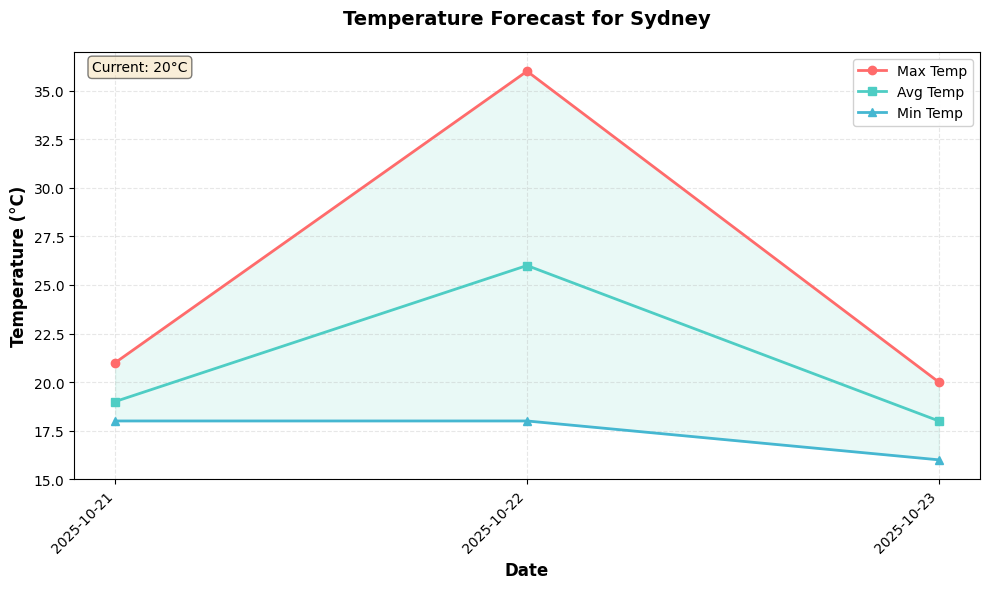

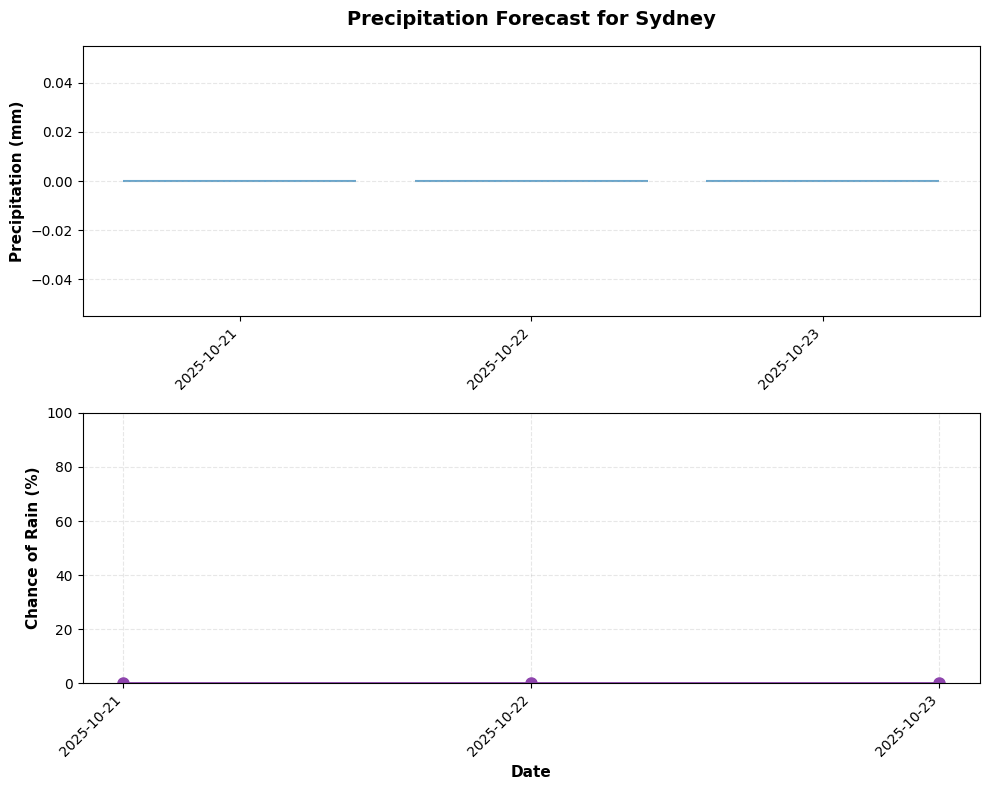

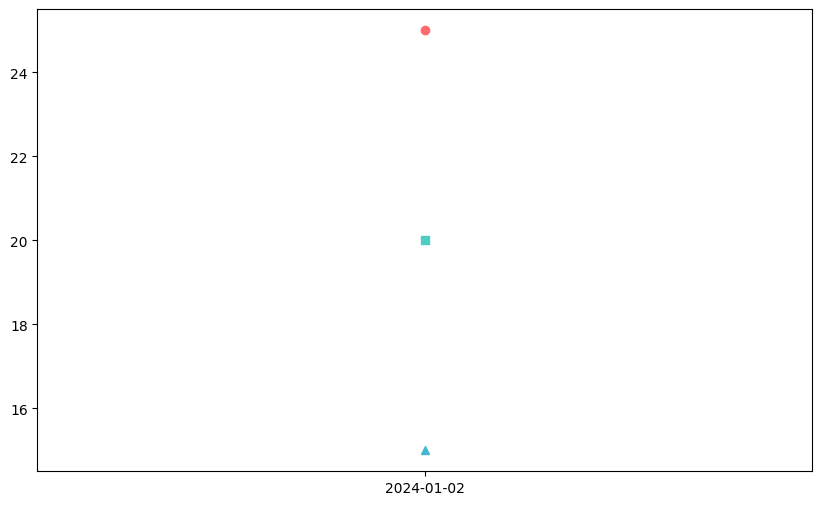

In [12]:
def run_comprehensive_tests():
    """Run comprehensive tests covering multiple locations and edge cases."""
    
    print("="*80)
    print("🌦️ COMPREHENSIVE WEATHERWISE TESTING SUITE")
    print("="*80)
    
    # Test locations from different continents
    test_locations = [
        "London",      # Europe
        "New York",    # North America  
        "Sydney",      # Australia
        "Tokyo",       # Asia
        "Mumbai",      # India
        "São Paulo",   # South America
        "Cairo",       # Africa
        "InvalidCity12345"  # Edge case
    ]
    
    # Test different forecast days
    forecast_days_tests = [1, 3, 5]
    
    # Test different question types
    test_questions = [
        "What's the temperature in London today?",
        "Will it rain in Sydney tomorrow?", 
        "How's the weather in Tokyo this week?",
        "Is it windy in Mumbai today?",
        "What's the humidity in New York tomorrow?",
        "Will it be sunny in Cairo this week?",
        "What's the weather like in São Paulo today?",  # No specific attribute
        "Temperature in InvalidCity12345 tomorrow?"     # Invalid location
    ]
    
    print("\n📍 TESTING MULTIPLE LOCATIONS")
    print("-" * 50)
    
    successful_locations = 0
    failed_locations = 0
    
    for location in test_locations:
        print(f"\nTesting: {location}")
        weather_data = get_weather_data(location, forecast_days=3)
        
        if weather_data:
            print(f"✅ SUCCESS - {location}")
            print(f"   Current: {weather_data['current']['temperature']}°C")
            print(f"   Forecast days: {len(weather_data['forecast'])}")
            successful_locations += 1
        else:
            print(f"❌ FAILED - {location}")
            failed_locations += 1
    
    print(f"\nLocation Test Results: {successful_locations} successful, {failed_locations} failed")
    
    print("\n📊 TESTING FORECAST DAYS")
    print("-" * 50)
    
    test_location = "London"  # Use a reliable location
    for days in forecast_days_tests:
        print(f"\nTesting {days} day(s) forecast for {test_location}:")
        weather_data = get_weather_data(test_location, forecast_days=days)
        
        if weather_data:
            actual_days = len(weather_data['forecast'])
            print(f"✅ Requested: {days}, Got: {actual_days} days")
        else:
            print(f"❌ Failed to get {days} day forecast")
    
    print("\n🤖 TESTING NATURAL LANGUAGE PROCESSING")
    print("-" * 50)
    
    nlp_success = 0
    nlp_failed = 0
    
    for question in test_questions:
        print(f"\nQuestion: {question}")
        parsed = parse_weather_question(question)
        
        print(f"   Location: {parsed['location']}")
        print(f"   Time: {parsed['time_period']}")
        print(f"   Attribute: {parsed['attribute']}")
        
        # Test if parsing makes sense
        if parsed['location'] and parsed['time_period'] and parsed['attribute']:
            print("   ✅ Parsing successful")
            nlp_success += 1
        else:
            print("   ⚠️ Parsing incomplete")
            nlp_failed += 1
    
    print(f"\nNLP Test Results: {nlp_success} successful, {nlp_failed} incomplete")
    
    print("\n📈 TESTING VISUALIZATIONS")
    print("-" * 50)
    
    viz_location = "Sydney"  # Use a reliable location
    weather_data = get_weather_data(viz_location, forecast_days=5)
    
    if weather_data:
        print(f"\nTesting visualizations for {viz_location}:")
        
        # Test temperature visualization
        try:
            fig1 = create_temperature_visualisation(weather_data, output_type='figure')
            if fig1:
                print("✅ Temperature visualization created successfully")
            else:
                print("❌ Temperature visualization failed")
        except Exception as e:
            print(f"❌ Temperature visualization error: {e}")
        
        # Test precipitation visualization  
        try:
            fig2 = create_precipitation_visualisation(weather_data, output_type='figure')
            if fig2:
                print("✅ Precipitation visualization created successfully")
            else:
                print("❌ Precipitation visualization failed")
        except Exception as e:
            print(f"❌ Precipitation visualization error: {e}")
    else:
        print(f"❌ Could not get weather data for visualization testing")
    
    print("\n🔄 TESTING EDGE CASES")
    print("-" * 50)
    
    edge_cases = [
        ("Empty string", ""),
        ("Numbers only", "12345"),
        ("Special characters", "!@#$%"),
        ("Very long name", "A" * 100),
        ("Mixed case", "LoNdOn"),
        ("With spaces", "New York City"),
        ("With commas", "London, UK"),
        ("None input", None)
    ]
    
    edge_success = 0
    edge_failed = 0
    
    for case_name, test_input in edge_cases:
        print(f"\nTesting edge case: {case_name}")
        try:
            if test_input is None:
                weather_data = get_weather_data(None)
            else:
                weather_data = get_weather_data(test_input)
            
            if weather_data is None:
                print(f"   ✅ Correctly handled invalid input")
                edge_success += 1
            else:
                print(f"   ⚠️ Unexpectedly returned data for invalid input")
                edge_failed += 1
        except Exception as e:
            print(f"   ✅ Correctly raised exception: {type(e).__name__}")
            edge_success += 1
    
    print(f"\nEdge Case Results: {edge_success} handled correctly, {edge_failed} unexpected")
    
    print("\n🚨 TESTING ERROR HANDLING")
    print("-" * 50)
    
    # Test invalid forecast_days parameter
    print("\nTesting invalid forecast_days parameter:")
    test_cases = [0, -1, 6, 10, "invalid", None, 3.5]
    
    for days in test_cases:
        print(f"   Testing forecast_days = {days}")
        weather_data = get_weather_data("London", forecast_days=days)
        if weather_data:
            actual_days = len(weather_data['forecast'])
            print(f"   ✅ Got {actual_days} days (should be 1-5)")
        else:
            print(f"   ❌ Failed to get weather data")
    
    # Test visualization with missing data
    print("\nTesting visualization error handling:")
    
    # Create mock data with missing fields
    mock_data_missing = {
        'location': 'Test City',
        'current': {'temperature': 'N/A'},
        'forecast': [
            {'date': '2024-01-01', 'max_temp': 'N/A', 'min_temp': 'N/A', 'avg_temp': 'N/A'},
            {'date': '2024-01-02', 'max_temp': '25', 'min_temp': '15', 'avg_temp': '20'}
        ]
    }
    
    print("   Testing temperature visualization with missing data:")
    try:
        fig = create_temperature_visualisation(mock_data_missing, output_type='figure')
        if fig:
            print("   ✅ Handled missing data gracefully")
        else:
            print("   ❌ Failed to handle missing data")
    except Exception as e:
        print(f"   ❌ Error with missing data: {e}")
    
    print("\n⚡ TESTING PERFORMANCE")
    print("-" * 50)
    
    import time
    
    # Test multiple rapid requests
    perf_locations = ["London", "Paris", "Tokyo", "Sydney", "New York"]
    
    print(f"\nTesting {len(perf_locations)} rapid requests:")
    
    start_time = time.time()
    successful_requests = 0
    
    for i, location in enumerate(perf_locations, 1):
        print(f"   Request {i}: {location}")
        request_start = time.time()
        
        weather_data = get_weather_data(location, forecast_days=3)
        
        request_time = time.time() - request_start
        
        if weather_data:
            print(f"   ✅ Success in {request_time:.2f}s")
            successful_requests += 1
        else:
            print(f"   ❌ Failed in {request_time:.2f}s")
    
    total_time = time.time() - start_time
    avg_time = total_time / len(perf_locations)
    
    print(f"\n📊 Performance Results:")
    print(f"   Total time: {total_time:.2f} seconds")
    print(f"   Average time per request: {avg_time:.2f} seconds")
    print(f"   Successful requests: {successful_requests}/{len(perf_locations)}")
    print(f"   Success rate: {(successful_requests/len(perf_locations)*100):.1f}%")
    
    # Performance benchmarks
    if avg_time < 2.0:
        print("   🚀 EXCELLENT performance (< 2s average)")
    elif avg_time < 5.0:
        print("   ✅ GOOD performance (< 5s average)")
    elif avg_time < 10.0:
        print("   ⚠️ ACCEPTABLE performance (< 10s average)")
    else:
        print("   ❌ SLOW performance (> 10s average)")
    
    print("\n🎯 TESTING USER INTERFACE COMPONENTS")
    print("-" * 50)
    
    # Test menu options (simulate without actual user input)
    print("Testing menu system components:")
    
    # Test main menu function exists and is callable
    try:
        import inspect
        if 'main_menu' in globals():
            print("✅ main_menu function exists")
        else:
            print("❌ main_menu function missing")
            
        if 'run_weather_advisor' in globals():
            print("✅ run_weather_advisor function exists")
        else:
            print("❌ run_weather_advisor function missing")
            
        if 'ask_weather_question' in globals():
            print("✅ ask_weather_question function exists")
        else:
            print("❌ ask_weather_question function missing")
            
    except Exception as e:
        print(f"❌ UI testing error: {e}")
    
    print("\n" + "="*80)
    print("🏁 COMPREHENSIVE TESTING COMPLETED")
    print("="*80)
    
    # Summary
    total_tests = len(test_locations) + len(forecast_days_tests) + len(test_questions) + len(edge_cases) + len(perf_locations)
    print(f"\n📊 FINAL TEST SUMMARY:")
    print(f"   Locations tested: {len(test_locations)}")
    print(f"   Forecast periods tested: {len(forecast_days_tests)}")
    print(f"   NLP questions tested: {len(test_questions)}")
    print(f"   Edge cases tested: {len(edge_cases)}")
    print(f"   Performance requests: {len(perf_locations)}")
    print(f"   Total test scenarios: {total_tests}")
    
    return {
        'locations_successful': successful_locations,
        'locations_failed': failed_locations,
        'nlp_successful': nlp_success,
        'nlp_failed': nlp_failed,
        'edge_cases_handled': edge_success,
        'edge_cases_failed': edge_failed,
        'performance_successful': successful_requests,
        'performance_failed': len(perf_locations) - successful_requests,
        'avg_response_time': avg_time
    }

# Run the comprehensive test suite
print("Starting comprehensive testing...")
test_results = run_comprehensive_tests()

print("\n" + "="*60)
print("ALL TESTS COMPLETED")
print("="*60)